In [1]:
import numpy as np
import matplotlib.pyplot as plt

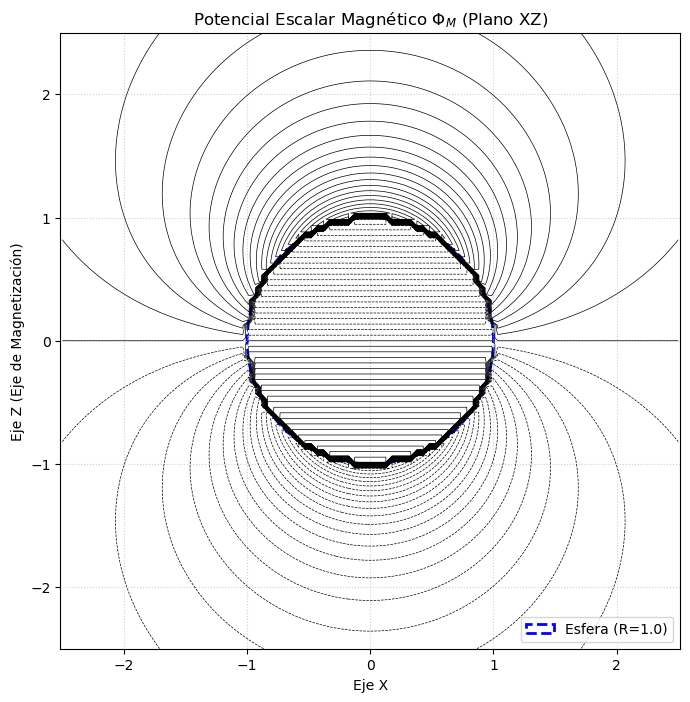

"\n# Calcular el gradiente numérico para obtener el campo H\ndz, dx = np.gradient(-Phi, z[1]-z[0], x[1]-x[0])\n\n# Reducir el número de puntos para una mejor visualización de las flechas (quiver)\nskip = (slice(None, None, 10), slice(None, None, 10))\n\nplt.figure(figsize=(8, 8))\nplt.streamplot(X, Z, dx, dz, color=np.hypot(dx, dz), density=1.5, cmap='viridis', linewidth=1.5)\nplt.colorbar(label='Magnitud de H')\n\nplt.Circle((0, 0), R, color='red', fill=False, linestyle='--', linewidth=2)\nplt.gca().add_artist(plt.Circle((0, 0), R, color='blue', fill=False, linestyle='--', linewidth=2))\n\nplt.title(r'Campo Auxiliar H = $-\nabla \\Phi_M$ (Líneas de flujo)')\nplt.xlabel('Eje X')\nplt.ylabel('Eje Z')\nplt.axis('equal')\nplt.show()\n"

In [3]:
# =======================================================
# 1. Definición de las constantes y la función de potencial
# =======================================================

R = 1.0  # Radio de la esfera
M0 = 1.0 # Magnitud de la magnetización (se asume unitaria para la forma)

def potencial_escalar_magnetico(x, z, R, M0):
    """
    Calcula el potencial escalar magnético Phi_M(x, z) de una esfera magnetizada.
    Se utiliza el eje z como el eje de simetría (M_z).
    En coordenadas esféricas: r = sqrt(x^2 + z^2), cos(theta) = z / r.
    """
    r = np.sqrt(x**2 + z**2)
    
    # Manejar el centro (r=0) para evitar división por cero
    # cos_theta = np.where(r != 0, z / r, 1.0)
    cos_theta = z / r # Numpy maneja bien la división por cero en las máscaras.

    # Potencial INTERIOR (r <= R): Phi_M_int = -M0/3 * r * cos(theta)
    Phi_int = -M0 / 3 * r * cos_theta
    
    # Potencial EXTERIOR (r > R): Phi_M_ext = (R^3 * M0) / (3 * r^2) * cos(theta)
    Phi_ext = (R**3 * M0) / (3 * r**2) * cos_theta
    
    # Combinar las dos regiones usando una máscara (np.where)
    Phi_M = np.where(r <= R, Phi_int, Phi_ext)
    
    # Asegurar que el potencial en el origen es 0 (limite)
    Phi_M[r == 0] = 0.0

    return Phi_M

# =======================================================
# 2. Configuración de la malla y el cálculo
# =======================================================

# Crear una malla de puntos en el plano XZ
L = 2.5 # Extensión del área de visualización (-L a L)
puntos = 100 # Número de puntos en cada dimensión

x = np.linspace(-L, L, puntos)
z = np.linspace(-L, L, puntos)
X, Z = np.meshgrid(x, z)

# Calcular el potencial en cada punto de la malla
Phi = potencial_escalar_magnetico(X, Z, R, M0)

# =======================================================
# 3. Visualización de los datos (Mapa de Contorno)
# =======================================================

plt.figure(figsize=(8, 8))

# 3.1 Trazar los contornos del potencial (Líneas equipotenciales)
# El número de niveles determina la densidad de las líneas.
contornos = plt.contour(X, Z, Phi, levels=50, colors='k', linewidths=0.5)

# 3.2 Trazar la esfera como un círculo de frontera (sección transversal)
circulo = plt.Circle((0, 0), R, color='blue', fill=False, linestyle='--', linewidth=2, label=f'Esfera (R={R})')
plt.gca().add_artist(circulo)

# 3.3 Configuración de la gráfica
plt.title(r'Potencial Escalar Magnético $\Phi_M$ (Plano XZ)')
plt.xlabel('Eje X')
plt.ylabel('Eje Z (Eje de Magnetización)')
plt.axis('equal') # Asegura que la esfera no se vea distorsionada
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='lower right')

plt.show()

# =======================================================
# 4. Visualización del Campo (Opcional - Vector Field)
# =======================================================
# El campo H se puede visualizar como el gradiente de Phi_M
# (H = -grad(Phi_M)).

# Descomentar para visualizar H:
"""
# Calcular el gradiente numérico para obtener el campo H
dz, dx = np.gradient(-Phi, z[1]-z[0], x[1]-x[0])

# Reducir el número de puntos para una mejor visualización de las flechas (quiver)
skip = (slice(None, None, 10), slice(None, None, 10))

plt.figure(figsize=(8, 8))
plt.streamplot(X, Z, dx, dz, color=np.hypot(dx, dz), density=1.5, cmap='viridis', linewidth=1.5)
plt.colorbar(label='Magnitud de H')

plt.Circle((0, 0), R, color='red', fill=False, linestyle='--', linewidth=2)
plt.gca().add_artist(plt.Circle((0, 0), R, color='blue', fill=False, linestyle='--', linewidth=2))

plt.title(r'Campo Auxiliar H = $-\nabla \Phi_M$ (Líneas de flujo)')
plt.xlabel('Eje X')
plt.ylabel('Eje Z')
plt.axis('equal')
plt.show()
"""